# 02 — Data Split & Sanity Check

Builds `data/manifest.csv` with columns `hr_path, lr_path, aoi, split`.

**Split strategy:** stratified by AOI — each terrain type contributes tiles to every split.
This ensures the model trains on all four terrains and test scores reflect performance across all of them.

| Split | Fraction |
|-------|----------|
| train | 70% |
| val   | 15% |
| test  | 15% |

In [18]:
import sys
from pathlib import Path
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

sys.path.insert(0, str(Path('../src').resolve()))

HR_DIR   = Path('../data/tiles_hr')
LR_DIR   = Path('../data/tiles_lr')
MANIFEST = Path('../data/manifest.csv')

TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15
# remaining 15% → test
SEED = 42

print('Dirs exist:', HR_DIR.exists(), LR_DIR.exists())

Dirs exist: True True


## Step 1: Inventory

In [19]:
hr_files = sorted(HR_DIR.glob('*.png'))
print(f'Total HR tiles: {len(hr_files)}')

from collections import Counter
aoi_counts = Counter(f.stem.rsplit('_', 1)[0] for f in hr_files)
for aoi, count in sorted(aoi_counts.items()):
    print(f'  {aoi:<30} {count:>4} tiles')

Total HR tiles: 527
  fishbone-deforestation          132 tiles
  iowa-farmland                   130 tiles
  long-beach-port                 132 tiles
  urban-philly                    133 tiles


## Step 2: Sanity check — every HR tile has a matching LR

In [20]:
missing = [f for f in hr_files if not (LR_DIR / f.name).exists()]
print(f'Missing LR pairs: {len(missing)}')
if missing:
    print('  ', [f.name for f in missing[:5]])

# Check a sample of shapes
import random
sample = random.sample(hr_files, min(10, len(hr_files)))
shape_ok = True
for hr_path in sample:
    hr = np.array(Image.open(hr_path))
    lr = np.array(Image.open(LR_DIR / hr_path.name))
    if hr.shape != (128, 128, 3) or lr.shape != (32, 32, 3):
        print(f'  BAD shapes: {hr_path.name}  HR={hr.shape}  LR={lr.shape}')
        shape_ok = False
if shape_ok:
    print('Shape check passed: all sampled tiles are 128x128 HR / 32x32 LR')

Missing LR pairs: 0
Shape check passed: all sampled tiles are 128x128 HR / 32x32 LR


## Step 3: Build and save manifest

In [21]:
random.seed(SEED)

rows = []
for hr_path in hr_files:
    aoi = hr_path.stem.rsplit('_', 1)[0]
    rows.append({
        'hr_path': str(hr_path.resolve()),
        'lr_path': str((LR_DIR / hr_path.name).resolve()),
        'aoi':     aoi,
        'split':   'pending',
    })

df = pd.DataFrame(rows)

# Stratified split: shuffle within each AOI, then assign by fraction
for aoi, group in df.groupby('aoi'):
    idx = group.index.tolist()
    random.shuffle(idx)
    n = len(idx)
    n_train = int(n * TRAIN_FRAC)
    n_val   = int(n * VAL_FRAC)
    df.loc[idx[:n_train],          'split'] = 'train'
    df.loc[idx[n_train:n_train+n_val], 'split'] = 'val'
    df.loc[idx[n_train+n_val:],    'split'] = 'test'

df.to_csv(MANIFEST, index=False)

print(df.groupby(['aoi', 'split']).size().unstack().to_string())
print(f'Total  train={(df.split=="train").sum()}  val={(df.split=="val").sum()}  test={(df.split=="test").sum()}')
print(f'Manifest saved → {MANIFEST}')

split                   test  train  val
aoi                                     
fishbone-deforestation    21     92   19
iowa-farmland             20     91   19
long-beach-port           21     92   19
urban-philly              21     93   19
Total  train=368  val=76  test=83
Manifest saved → ../data/manifest.csv


## Step 4: Pixel value distributions per AOI

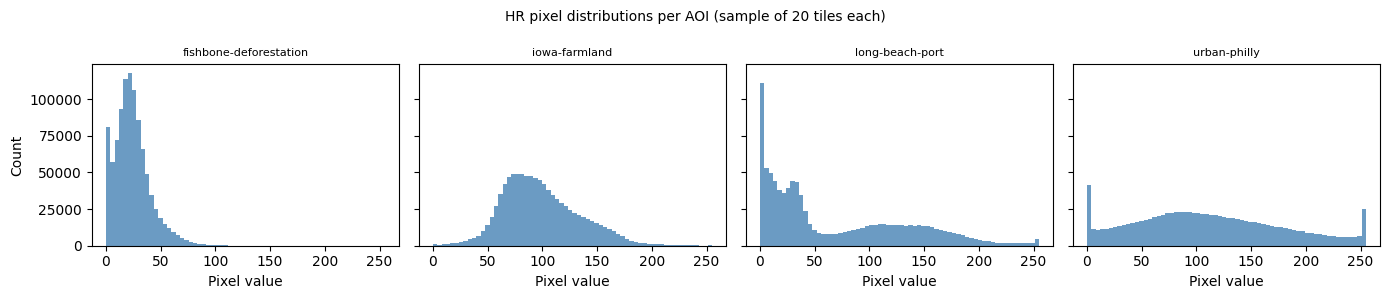

In [22]:
aois = sorted(set(f.stem.rsplit('_', 1)[0] for f in hr_files))
fig, axes = plt.subplots(1, len(aois), figsize=(14, 3), sharey=True)

for ax, aoi in zip(axes, aois):
    aoi_files = [f for f in hr_files if f.stem.rsplit('_', 1)[0] == aoi]
    sample = random.sample(aoi_files, min(20, len(aoi_files)))
    pixels = np.concatenate([np.array(Image.open(f)).ravel() for f in sample])
    ax.hist(pixels, bins=64, range=(0, 255), color='steelblue', alpha=0.8)
    ax.set_title(aoi, fontsize=8)
    ax.set_xlabel('Pixel value')

axes[0].set_ylabel('Count')
plt.suptitle('HR pixel distributions per AOI (sample of 20 tiles each)', fontsize=10)
plt.tight_layout()
plt.savefig('../figures/pixel_distributions.png', bbox_inches='tight')
plt.show()